In [2]:
# ─────────────────────────────────────────────
# CELL 1: Konfigurasi Path & Setup
# ─────────────────────────────────────────────
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("  🛠️ REVISI MASTER DATASET (GALLERY ONLY)")
print("="*60)

BASE_DIR = r'd:\Antigravity\Visual Based Rekomender Sistem'
OUTPUT_DIR = os.path.join(BASE_DIR, 'skripsi', 'persiapan_skripsi', 'data preperation')

FULL_CSV = os.path.join(OUTPUT_DIR, 'full_dataset.csv')
if not os.path.exists(FULL_CSV):
    FULL_CSV = os.path.join(BASE_DIR, 'dataset', 'full_dataset.csv')

MASTER_CSV_GALLERY = os.path.join(OUTPUT_DIR, 'master_dataset_gallery.csv')

if not os.path.exists(FULL_CSV):
    raise FileNotFoundError(f"❌ File {FULL_CSV} tidak ditemukan!")

print(f"📦 Memuat dataset dari: {FULL_CSV}")


  🛠️ REVISI MASTER DATASET (GALLERY ONLY)
📦 Memuat dataset dari: d:\Antigravity\Visual Based Rekomender Sistem\dataset\full_dataset.csv


In [3]:
# ─────────────────────────────────────────────
# CELL 2: Memuat Data & Filter Label 'Gallery'
# ─────────────────────────────────────────────
df_full = pd.read_csv(FULL_CSV)

print("\n🔍 Memfilter data khusus label 'gallery'...")
df_gallery = df_full[df_full['split'] == 'gallery'].reset_index(drop=True)

print(f"   Total gambar (gallery split)   : {len(df_gallery):,}")
print(f"   Total item unik (gallery split): {df_gallery['item_id'].nunique():,}")



🔍 Memfilter data khusus label 'gallery'...
   Total gambar (gallery split)   : 12,612
   Total item unik (gallery split): 3,985


In [4]:
# ─────────────────────────────────────────────
# CELL 3: Pemilihan 1 Gambar Representatif (Prioritas Pose)
# ─────────────────────────────────────────────
PREFERRED_POSES = ['front', 'side', 'full', 'back', 'zoom-in', 'flat']

def get_best_image_per_item(df):
    selected = []
    for item_id, group in tqdm(df.groupby('item_id'), desc="Selecting best image per item"):
        for pose in PREFERRED_POSES:
            subset = group[group['pose_type_label'] == pose]
            if len(subset) > 0:
                selected.append(subset.iloc[0])
                break
        else:
            selected.append(group.iloc[0])  # fallback
    return pd.DataFrame(selected).reset_index(drop=True)

df_representative = get_best_image_per_item(df_gallery)
print(f"\n✅ {len(df_representative):,} item representatif berhasil dipiilih (1 foto per item).")


Selecting best image per item: 100%|██████████| 3985/3985 [00:01<00:00, 3138.52it/s]



✅ 3,985 item representatif berhasil dipiilih (1 foto per item).


In [5]:
# ─────────────────────────────────────────────
# CELL 4: Filter Kategori dengan Item Cukup
# ─────────────────────────────────────────────
MIN_ITEMS_PER_CATEGORY = 20
cat_item_count = df_representative.groupby('category')['item_id'].nunique()
valid_categories = cat_item_count[cat_item_count >= MIN_ITEMS_PER_CATEGORY].index.tolist()

df_final = df_representative[df_representative['category'].isin(valid_categories)].reset_index(drop=True)
df_final['db_idx'] = df_final.index

print(f"\n📊 Statistik Setelah Filter (Min {MIN_ITEMS_PER_CATEGORY} Item/Kategori):")
print(f"   Kategori valid : {df_final['category'].nunique()}")
print(f"   Total item     : {len(df_final):,}")



📊 Statistik Setelah Filter (Min 20 Item/Kategori):
   Kategori valid : 16
   Total item     : 3,981


In [5]:
# ─────────────────────────────────────────────
# CELL 5: Menyimpan Hasil Dataset Master
# ─────────────────────────────────────────────
df_final.to_csv(MASTER_CSV_GALLERY, index=False)
print(f"\n💾 master_dataset_gallery.csv berhasil tersimpan di:\n   {MASTER_CSV_GALLERY}")
print("="*60)



💾 master_dataset_gallery.csv berhasil tersimpan di:
   d:\Antigravity\Visual Based Rekomender Sistem\skripsi\persiapan_skripsi\data preperation\master_dataset_gallery.csv



📊 Membangun visualisasi distribusi data...


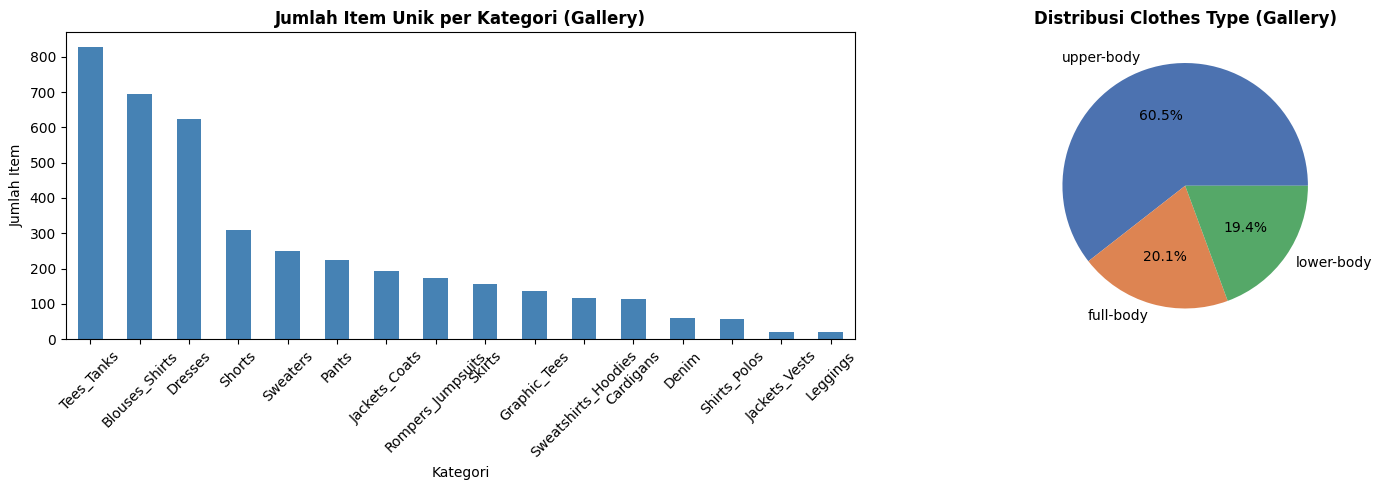

In [6]:
# ─────────────────────────────────────────────
# CELL 6: Visualisasi Distribusi Kategori & Tipe Pakaian
# ─────────────────────────────────────────────
print("\n📊 Membangun visualisasi distribusi data...")
cat_counts = df_final.groupby('category')['item_id'].nunique().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart: Jumlah item unik per kategori
cat_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Jumlah Item Unik per Kategori (Gallery)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Kategori')
axes[0].set_ylabel('Jumlah Item')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart: Distribusi clothes_type
clothes_dist = df_final['clothes_type_label'].value_counts()
axes[1].pie(clothes_dist.values, labels=clothes_dist.index, autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452', '#55A868'])
axes[1].set_title('Distribusi Clothes Type (Gallery)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()



📷 Membangun visualisasi sampel gambar per kategori...


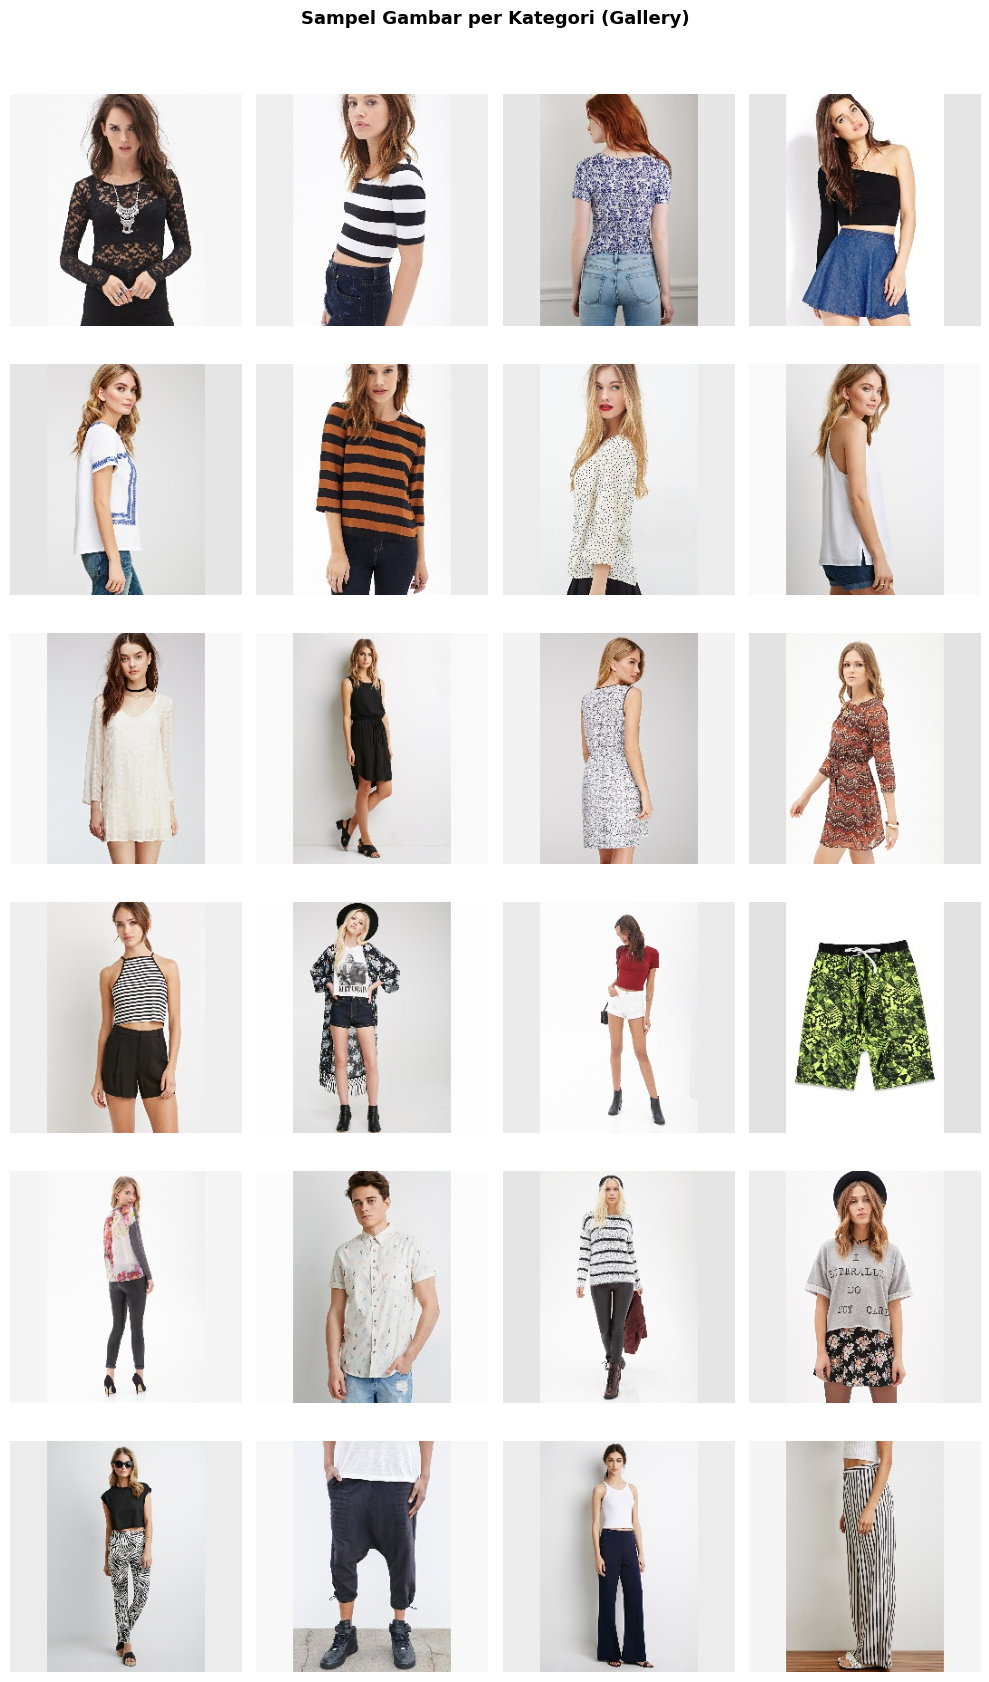

In [8]:
# ─────────────────────────────────────────────
# CELL 7: Visualisasi Sampel Gambar
# ─────────────────────────────────────────────
print("\n📷 Membangun visualisasi sampel gambar per kategori...")
def show_sample_images(df, n_categories=6, n_per_cat=4):
    cats = df['category'].value_counts().head(n_categories).index.tolist()
    fig, axes = plt.subplots(n_categories, n_per_cat, figsize=(n_per_cat * 2.5, n_categories * 2.8))

    # Pastikan IMG_DIR diarahkan ke folder Img yang benar
    IMG_DIR = os.path.join(BASE_DIR, 'dataset', 'In-shop Clothes Retrieval Benchmark', 'Img')

    for r, cat in enumerate(cats):
        cat_df = df[df['category'] == cat].sample(
            min(n_per_cat, len(df[df['category'] == cat])), random_state=42
        )
        for c, (_, row) in enumerate(cat_df.iterrows()):
            ax = axes[r, c]
            try:
                # Membangun path dinamis yang aman
                img_name_str = str(row['image_name'])
                if img_name_str.startswith('img/'):
                    img_path = os.path.join(IMG_DIR, os.path.normpath(img_name_str.replace('img/', '', 1)))
                else:
                    img_path = os.path.join(IMG_DIR, os.path.normpath(img_name_str))
                
                img = mpimg.imread(img_path)
                ax.imshow(img)
            except Exception as e:
                ax.text(0.5, 0.5, 'Error', ha='center', va='center', color='red')
            ax.axis('off')
            if c == 0:
                short_cat = cat.replace('_', ' ')
                ax.set_ylabel(short_cat, fontsize=7, rotation=0, ha='right', va='center')

    plt.suptitle('Sampel Gambar per Kategori (Gallery)', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

show_sample_images(df_final, n_categories=6, n_per_cat=4)


In [7]:
# ─────────────────────────────────────────────
# CELL 8: ANALISIS LENGKAP - Before vs After Filter
# ─────────────────────────────────────────────
print("\n" + "="*70)
print("  📊 ANALISIS LENGKAP: BEFORE vs AFTER FILTER")
print("="*70)

# ── 8.1: Statistik SEBELUM Filter (per split) ──
print("\n" + "─"*70)
print("  1. SEBELUM FILTER (Semua Data per Split)")
print("─"*70)

stats_before = df_full.groupby('split').agg(
    jumlah_gambar=('image_name', 'count'),
    jumlah_item=('item_id', 'nunique'),
    jumlah_kategori=('category', 'nunique')
).reset_index()

for _, row in stats_before.iterrows():
    print(f"\n   Split: {row['split'].upper()}")
    print(f"      Gambar   : {row['jumlah_gambar']:,}")
    print(f"      Item     : {row['jumlah_item']:,}")
    print(f"      Kategori : {row['jumlah_kategori']}")

# ── 8.2: Statistik SEBELUM Filter (per split x kategori) ──
print("\n" + "─"*70)
print("  2. SEBELUM FILTER - Detail per Kategori (per Split)")
print("─"*70)

cat_stats_before = df_full.groupby(['split', 'category']).agg(
    jumlah_gambar=('image_name', 'count'),
    jumlah_item=('item_id', 'nunique')
).reset_index()

for split in stats_before['split'].unique():
    print(f"\n   Split: {split.upper()}")
    split_data = cat_stats_before[cat_stats_before['split'] == split]
    for _, row in split_data.iterrows():
        print(f"      {row['category']:25s} | Item: {row['jumlah_item']:4d} | Gambar: {row['jumlah_gambar']:5d}")

# ── 8.3: Kategori yang DIBUANG (< 20 item) ──
print("\n" + "─"*70)
print("  3. KATEGORI YANG DIBUANG (< 20 ITEM)")
print("─"*70)

# Hitung item per kategori (di gallery split, setelah pilih 1 gambar/item)
cat_item_count_full = df_full[df_full['split'] == 'gallery'].groupby('category')['item_id'].nunique()
dropped_cats = cat_item_count_full[cat_item_count_full < MIN_ITEMS_PER_CATEGORY]

print(f"\n   Kategori dibuang ({len(dropped_cats)} kategori):")
total_dropped_items = 0
total_dropped_images = 0
for cat, count in dropped_cats.items():
    # Hitung total item & gambar di SEMUA split untuk kategori ini
    cat_data = df_full[df_full['category'] == cat]
    total_items = cat_data['item_id'].nunique()
    total_imgs = len(cat_data)
    total_dropped_items += total_items
    total_dropped_images += total_imgs
    print(f"      • {cat:25s} | Gallery Item: {count:4d} | Total Item: {total_items:4d} | Total Gambar: {total_imgs:5d}")

print(f"\n   Total item dibuang (semua split): {total_dropped_items:,}")
print(f"   Total gambar dibuang (semua split): {total_dropped_images:,}")

# ── 8.4: Ambang <20 dihitung per apa? ──
print("\n" + "─"*70)
print("  4. AMBANG '<20' - Penjelasan")
print("─"*70)
print(f"""
   Ambang <{MIN_ITEMS_PER_CATEGORY} dihitung PER ITEM (bukan per gambar).
   
   Cara kerja:
   1. Ambil gallery split dulu
   2. Pilih 1 gambar representatif per item → df_representative
   3. Hitung jumlah item_id UNIK per kategori
   4. Kategori dengan < {MIN_ITEMS_PER_CATEGORY} item_id → DIBUANG
   
   Contoh:
   - Kategori 'suiting' punya 15 item unik di gallery → DIBUANG
   - Kategori 'dress' punya 100 item unik di gallery → DIPERTAHANKAN
   
   Di split mana dihitung? → GALLERY SPLIT (master dataset)
""")

# ── 8.5: Statistik SESUDAH Filter (per split) ──
print("\n" + "─"*70)
print("  5. SESUDAH FILTER - Detail per Kategori (per Split)")
print("─"*70)

cat_stats_after = df_final.groupby(['split', 'category']).agg(
    jumlah_gambar=('image_name', 'count'),
    jumlah_item=('item_id', 'nunique')
).reset_index()

for split in ['train', 'query', 'gallery']:
    if split in cat_stats_after['split'].values:
        print(f"\n   Split: {split.upper()}")
        split_data = cat_stats_after[cat_stats_after['split'] == split]
        for _, row in split_data.iterrows():
            print(f"      {row['category']:25s} | Item: {row['jumlah_item']:4d} | Gambar: {row['jumlah_gambar']:5d}")

# ── 8.6: Summary After Filter ──
print("\n" + "─"*70)
print("  6. SESUDAH FILTER - Summary per Split")
print("─"*70)

stats_after = df_final.groupby('split').agg(
    jumlah_gambar=('image_name', 'count'),
    jumlah_item=('item_id', 'nunique'),
    jumlah_kategori=('category', 'nunique')
).reset_index()

for _, row in stats_after.iterrows():
    print(f"\n   Split: {row['split'].upper()}")
    print(f"      Gambar   : {row['jumlah_gambar']:,}")
    print(f"      Item     : {row['jumlah_item']:,}")
    print(f"      Kategori : {row['jumlah_kategori']}")

# ── 8.7: Split 80:20 ──
print("\n" + "─"*70)
print("  7. SETELAH SPLIT 80:20 (Train vs Validasi)")
print("─"*70)

# Cek apakah ada split info di df_final
if 'split' in df_final.columns:
    splits = df_final['split'].unique()
    print(f"\n   Split tersedia: {list(splits)}")
    
    for split in ['train', 'validation', 'query', 'gallery']:
        if split in splits:
            count = len(df_final[df_final['split'] == split])
            items = df_final[df_final['split'] == split]['item_id'].nunique()
            cats = df_final[df_final['split'] == split]['category'].nunique()
            print(f"\n   {split.upper()}:")
            print(f"      Gambar: {count:,} | Item: {items:,} | Kategori: {cats}")

print(f"\n   num_classes = {df_final['category'].nunique()} (jumlah kategori valid)")

# ── 8.8: Query/Gallery untuk Retrieval ──
print("\n" + "─"*70)
print("  8. QUERY & GALLERY UNTUK EVALUASI RETRIEVAL")
print("─"*70)

if 'query' in stats_after['split'].values or 'query' in df_full['split'].unique():
    query_df = df_final[df_final['split'] == 'query'] if 'query' in df_final['split'].unique() else df_full[df_full['split'] == 'query']
    print(f"\n   Query split (setelah filter):")
    print(f"      Gambar: {len(query_df):,} | Item: {query_df['item_id'].nunique():,} | Kategori: {query_df['category'].nunique()}")
    
    gallery_df = df_final[df_final['split'] == 'gallery']
    print(f"\n   Gallery split (setelah filter):")
    print(f"      Gambar: {len(gallery_df):,} | Item: {gallery_df['item_id'].nunique():,} | Kategori: {gallery_df['category'].nunique()}")
    
    print(f"\n   ✅ Query & Gallery JUGA membuang kategori < 20 item (termasuk Suiting)")
    print(f"   Karena filter diterapkan di gallery master, lalu train/query/gallery berasal dari master yang sama.")

# ── 8.9: Master Dataset 3985 → 3981 ──
print("\n" + "─"*70)
print("  9. MASTER DATASET: 3,985 → 3,981")
print("─"*70)

# Cek full dataset item count
full_items = df_full['item_id'].nunique()
final_items = df_final['item_id'].nunique()

print(f"\n   Full dataset (sebelum filter): {full_items:,} item")
print(f"   Master dataset (sesudah filter): {final_items:,} item")
print(f"   Selisih: {full_items - final_items:,} item")

# Cek kategori di full vs final
full_cats = set(df_full['category'].unique())
final_cats = set(df_final['category'].unique())
diff_cats = full_cats - final_cats

print(f"\n   Kategori di full dataset: {len(full_cats)}")
print(f"   Kategori di master dataset: {len(final_cats)}")
print(f"   Kategori hilang: {len(diff_cats)}")

if diff_cats:
    print(f"\n   Kategori yang hilang:")
    for cat in sorted(diff_cats):
        count = df_full[df_full['category'] == cat]['item_id'].nunique()
        print(f"      • {cat:25s} | {count} item")

# ── 8.10: Tabel Summary Lengkap ──
print("\n" + "─"*70)
print("  10. TABEL SUMMARY LENGKAP")
print("─"*70)

# Summary BEFORE filter (per split)
print("\n   SEBELUM FILTER:")
for _, row in stats_before.iterrows():
    print(f"      {row['split'].upper():10s} | Gambar: {row['jumlah_gambar']:6,d} | Item: {row['jumlah_item']:5,d} | Kategori: {row['jumlah_kategori']}")

# Summary AFTER filter (hanya gallery yang ada di df_final)
print("\n   SESUDAH FILTER (Gallery Master):")
for _, row in stats_after.iterrows():
    print(f"      {row['split'].upper():10s} | Gambar: {row['jumlah_gambar']:6,d} | Item: {row['jumlah_item']:5,d} | Kategori: {row['jumlah_kategori']}")

# Summary untuk Query (dari df_full, sebelum filter kategori)
print("\n   QUERY (dari df_full, sebelum filter):")
query_before = df_full[df_full['split'] == 'query']
print(f"      {'QUERY':10s} | Gambar: {len(query_before):6,d} | Item: {query_before['item_id'].nunique():5,d} | Kategori: {query_before['category'].nunique()}")

print("\n" + "="*70)
print("  ✅ ANALISIS SELESAI")
print("="*70)



  📊 ANALISIS LENGKAP: BEFORE vs AFTER FILTER

──────────────────────────────────────────────────────────────────────
  1. SEBELUM FILTER (Semua Data per Split)
──────────────────────────────────────────────────────────────────────

   Split: GALLERY
      Gambar   : 12,612
      Item     : 3,985
      Kategori : 17

   Split: QUERY
      Gambar   : 14,218
      Item     : 3,985
      Kategori : 17

   Split: TRAIN
      Gambar   : 25,882
      Item     : 3,997
      Kategori : 17

──────────────────────────────────────────────────────────────────────
  2. SEBELUM FILTER - Detail per Kategori (per Split)
──────────────────────────────────────────────────────────────────────

   Split: GALLERY
      Blouses_Shirts            | Item:  697 | Gambar:  1843
      Cardigans                 | Item:  115 | Gambar:   354
      Denim                     | Item:   60 | Gambar:   182
      Dresses                   | Item:  624 | Gambar:  1647
      Graphic_Tees              | Item:  136 | Gambar: